In [2]:
import pandas as pd
import numpy as np
pd.set_option("display.max_columns", None)
df = pd.read_csv("../data/processed/train_smote.csv")
print("Dataset Shape:", df.shape)

Dataset Shape: (1582354, 48)


Create New Features

In [3]:
# (a) Address Stability Score
# Higher value = customer stayed longer.
df["address_stability"] = (df["prev_address_months_count"] +df["current_address_months_count"])

In [4]:
# (b) Velocity Ratio
df["velocity_ratio"] = (df["velocity_24h"] /(df["velocity_6h"] + 1))

In [5]:
# (c) Phone Verification Score
df["phone_verification_score"] = (df["phone_home_valid"] +df["phone_mobile_valid"])

In [6]:
# (d) Banking Relationship
df["bank_relationship"] = (df["bank_months_count"] *(df["has_other_cards"] + 1))

In [7]:
# (e) Customer Trust Score
df["customer_trust_score"] = (df["credit_risk_score"] *df["name_email_similarity"])

In [8]:
# (f) Transaction Velocity Score
df["transaction_velocity_score"] = (df["velocity_6h"] +df["velocity_24h"] +df["velocity_4w"])

In [9]:
# (g) Digital Footprint Score
df["digital_footprint"] = (df["device_distinct_emails_8w"] +df["email_is_free"] +df["keep_alive_session"])

In [10]:
# Viewing  New Features
new_features = ["address_stability","velocity_ratio","phone_verification_score","bank_relationship",
                "customer_trust_score","transaction_velocity_score","digital_footprint"]
df[new_features].head()

,address_stability,velocity_ratio,phone_verification_score,bank_relationship,customer_trust_score,transaction_velocity_score,digital_footprint
0,97.0,0.502821,1,48.0,22.282078,25181.526146,2.0
1,223.0,0.652655,1,20.0,133.693656,20875.158423,2.0
2,97.0,1.250124,2,26.0,57.300798,8031.704263,3.0
3,156.0,0.846297,1,2.0,159.620824,14152.681371,2.0
4,112.0,0.655865,2,2.0,113.254447,16552.466907,2.0


In [11]:
# Correlation of New Features with Fraud
corr = df[new_features + ["fraud_bool"]].corr()
corr["fraud_bool"].sort_values(ascending=False)

fraud_bool                    1.000000
address_stability             0.133112
customer_trust_score          0.049595
velocity_ratio                0.014488
bank_relationship            -0.061762
transaction_velocity_score   -0.084900
digital_footprint            -0.336955
phone_verification_score     -0.466329
Name: fraud_bool, dtype: float64

<Axes: title={'center': 'Correlation of Engineered Features with Fraud'}>

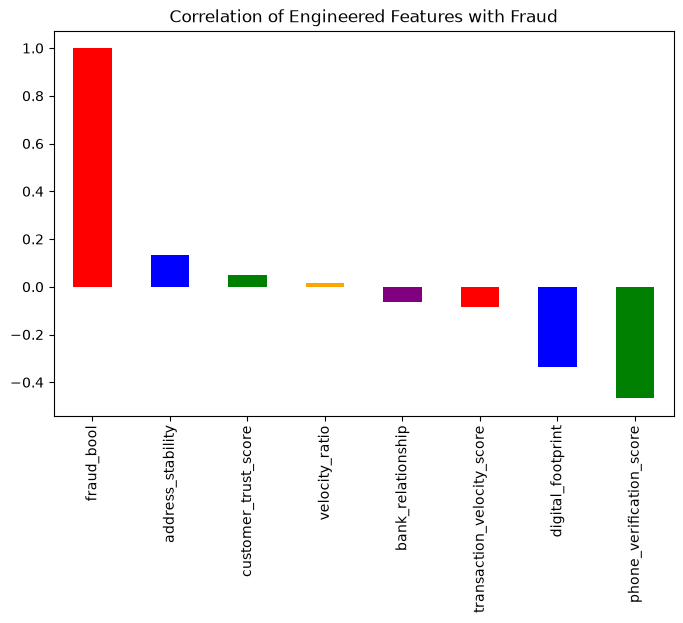

In [16]:
# Feature Importance Preview
colors = ["red", "blue", "green", "orange", "purple"]
corr["fraud_bool"].sort_values(ascending=False).plot(kind="bar",figsize=(8,5),
    title="Correlation of Engineered Features with Fraud",color=colors)

In [17]:
#Check Missing Values
df[new_features].isnull().sum()

address_stability             0
velocity_ratio                0
phone_verification_score      0
bank_relationship             0
customer_trust_score          0
transaction_velocity_score    0
digital_footprint             0
dtype: int64

In [18]:
df.to_csv("../data/processed/financial_fraud_feature_engineered.csv",index=False)
print("Feature engineered dataset saved successfully.")

Feature engineered dataset saved successfully.


# Summary
-Loaded the encoded fraud dataset.
-Engineered 7 new features to better represent customer behavior and transaction patterns.
-Examined correlations of the engineered features with the fraud target.
-Verified that the new features contained no missing values.
-Saved the enriched dataset as financial_fraud_feature_engineered.csv